<a href="https://colab.research.google.com/github/nikitos-net/The-exam-for-the-course-Machine-learning-/blob/main/ML_2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

**Демо-экзамен по курсу "Машинное обучение"**

Выполнил: Быков Никита Игоревич Б22-515

Филиал: НИЯУ МИФИ

 *Вставьте ниже скриншот из личного кабинета Иннополиса с результатами прохождения итогового асессмента (https://auth.unionepro.ru/login?redirect=https%3A%2F%2Fassessment.unionepro.ru%2F)*

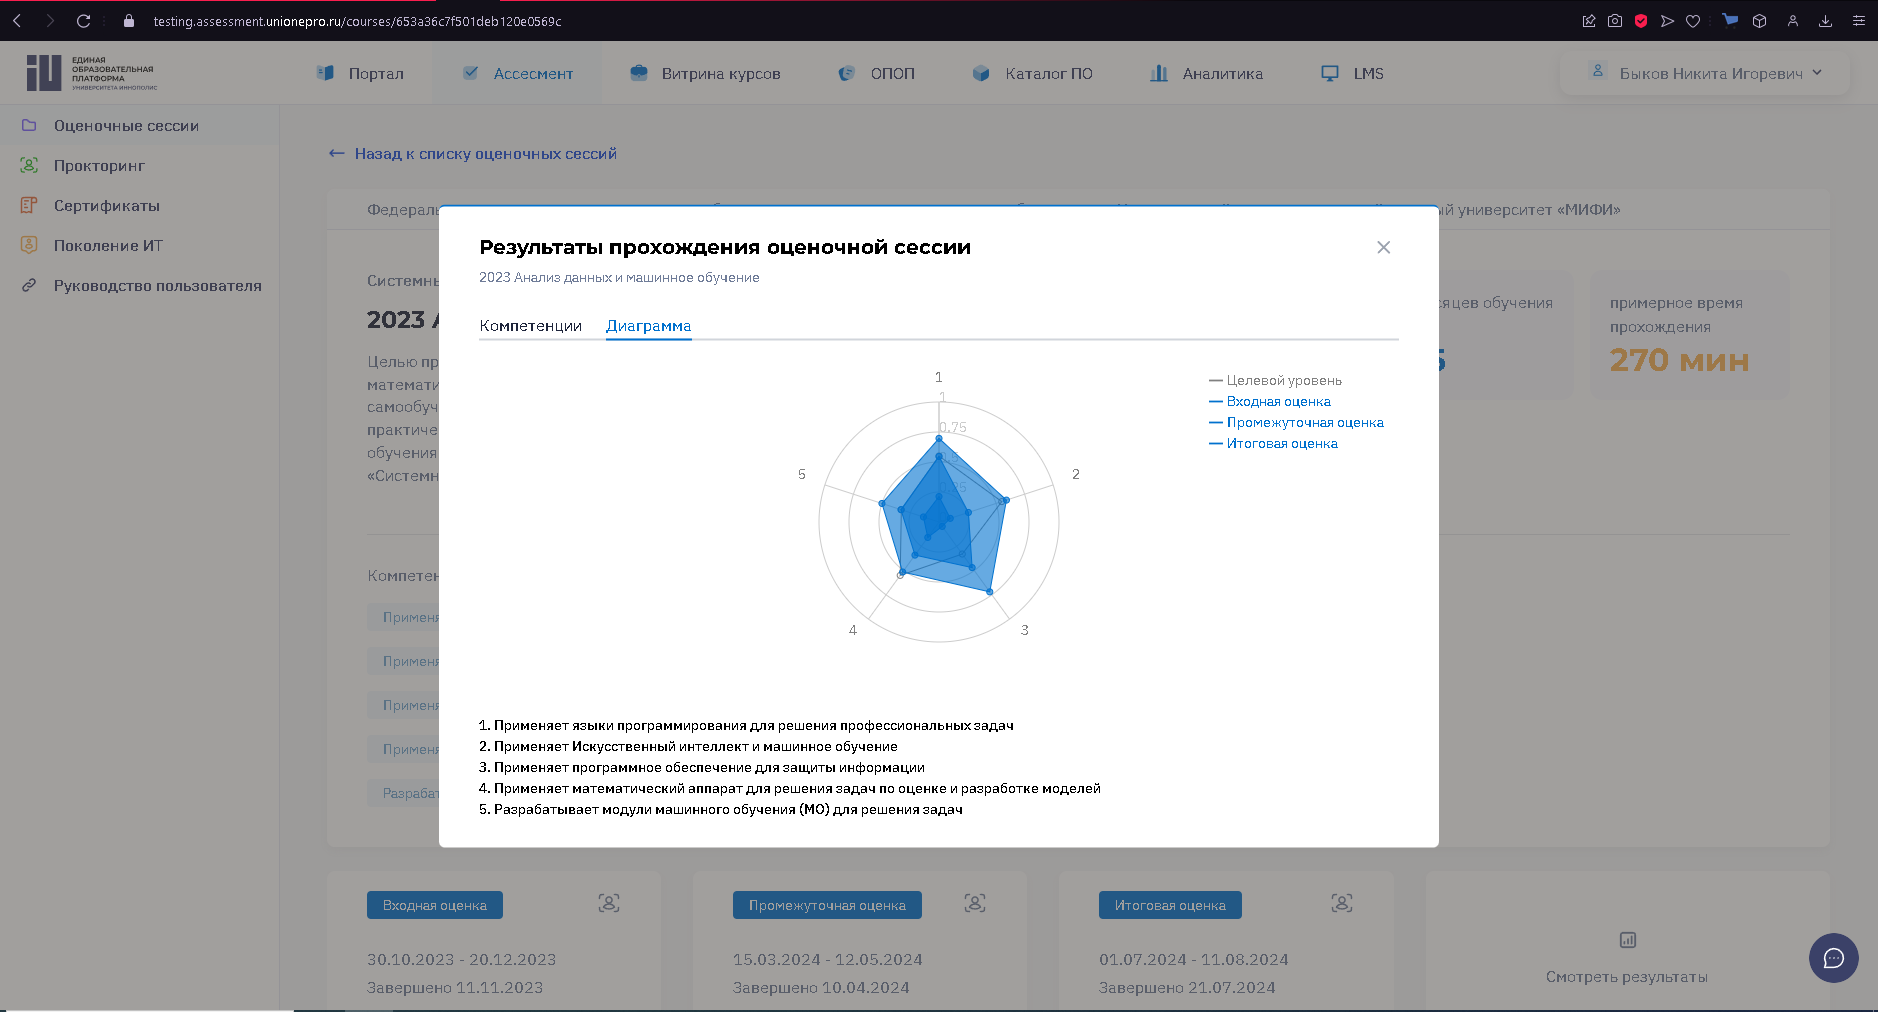

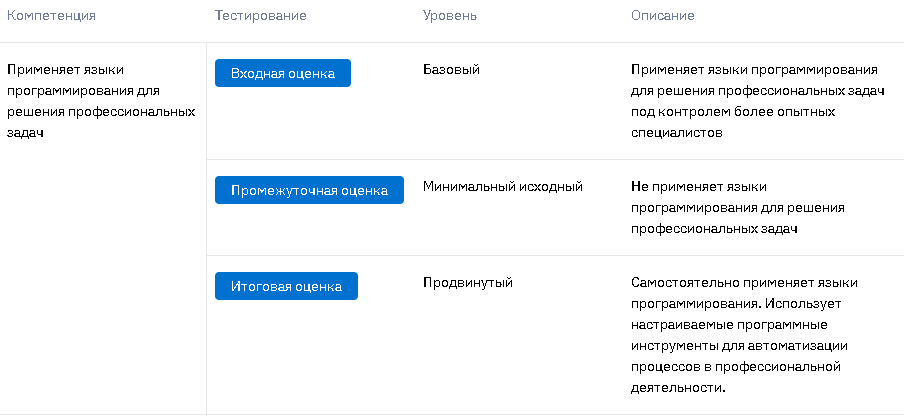

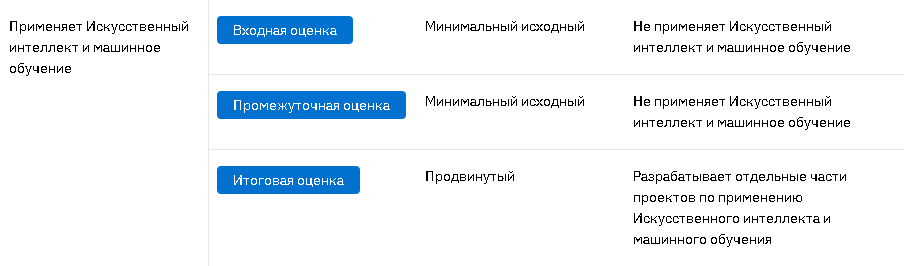

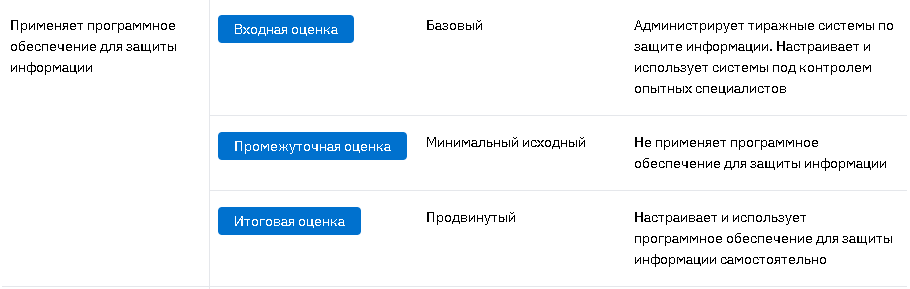

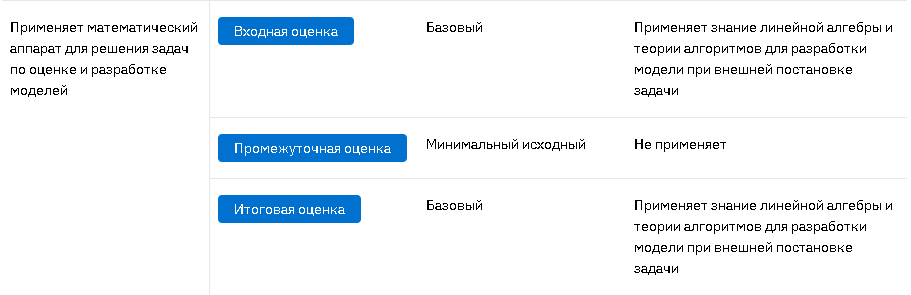

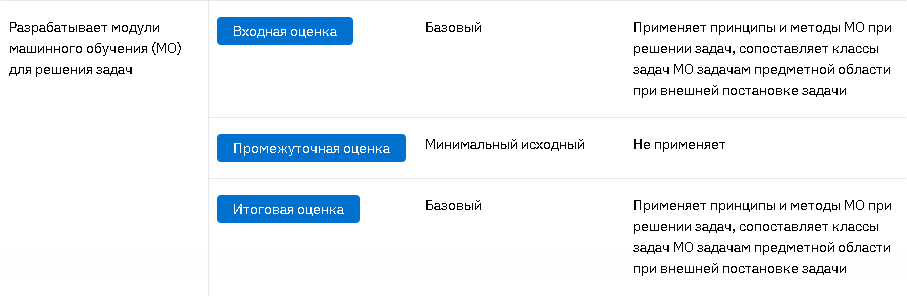

---
# 1. Исходные данные

### 1.1 Загрузка библиотек и данных


*Загрузить данные в соответствии с вариантом задания*

In [ ]:
# Load data
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.datasets import load_diabetes
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
import numpy as np
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.model_selection import KFold, cross_val_score
from sklearn import datasets, linear_model
from sklearn.neighbors import KNeighborsRegressor
from sklearn.metrics import mean_squared_error

data = load_diabetes()
data_df = pd.DataFrame(data=data.data, columns=data.feature_names)
data_df['target'] = data.target
data_df

,age,sex,bmi,bp,s1,s2,s3,s4,s5,s6,target
0,0.038076,0.050680,0.061696,0.021872,-0.044223,-0.034821,-0.043401,-0.002592,0.019907,-0.017646,151.0
1,-0.001882,-0.044642,-0.051474,-0.026328,-0.008449,-0.019163,0.074412,-0.039493,-0.068332,-0.092204,75.0
2,0.085299,0.050680,0.044451,-0.005670,-0.045599,-0.034194,-0.032356,-0.002592,0.002861,-0.025930,141.0
3,-0.089063,-0.044642,-0.011595,-0.036656,0.012191,0.024991,-0.036038,0.034309,0.022688,-0.009362,206.0
4,0.005383,-0.044642,-0.036385,0.021872,0.003935,0.015596,0.008142,-0.002592,-0.031988,-0.046641,135.0
...,...,...,...,...,...,...,...,...,...,...,...
437,0.041708,0.050680,0.019662,0.059744,-0.005697,-0.002566,-0.028674,-0.002592,0.031193,0.007207,178.0
438,-0.005515,0.050680,-0.015906,-0.067642,0.049341,0.079165,-0.028674,0.034309,-0.018114,0.044485,104.0
439,0.041708,0.050680,-0.015906,0.017293,-0.037344,-0.013840,-0.024993,-0.011080,-0.046883,0.015491,132.0
440,-0.045472,-0.044642,0.039062,0.001215,0.016318,0.015283,-0.028674,0.026560,0.044529,-0.025930,220.0


### 1.2 Описание исходных данных


*Привести описание исходных данных, описание и типы признаков (вещественные,
целочисленные, категориальные и т.д.), объём выборки, особенности данных. Сформулировать решаемую задачу, определить тип задачи (регрессия / классификация), указать входные и выходные переменные.*

> Добавить блок с цитатой



*   Объем выборки: 442
*   Колличество признаков: Первые 10 столбцов являются числовыми прогнозирующими значениями
*   Целевой столбец: Столбец 11 представляет собой количественный показатель прогрессирования заболевания через год после исходного уровня
*   Информация об атрибутах:
      age - возраст в годах,
      sex - пол,
      bmi - индекс массы тела,
      bp - среднее артериальное давление,
      s1 tc - общий холестерин сыворотки крови,
      s2 ldl - липопротеины низкой плотности,
      s3 hdl - липопротеины высокой плотности,
      s4 tch - общий холестерин / ЛПВП,
      s5 ltg - возможно, логарифм уровня триглицеридов в сыворотке крови,
      s6 glu - уровень сахара в крови
*   Каждая из этих 10 характерных переменных была центрирована по среднему значению и масштабирована на стандартное отклонение, умноженное на квадратный корень из количества образцов (т.е. сумма квадратов каждого столбца равна 1). Изначально набор данных выглядел так:

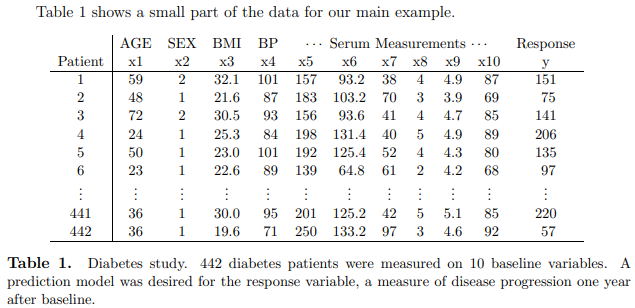

*   Дополнительная информация:

      https://scikit-learn.org/stable/datasets/toy_dataset.html#diabetes-dataset
      https://web.stanford.edu/~hastie/Papers/LARS/LeastAngle_2002.pdf
*   Сформулированая задача: Исследование прогназирования развития диабета с помощью регресионной модели.

### 1.3 Выборочные характеристики

*Рассчитать основные выборочные характеристики (среднее, дисперсию, среднеквадратическое отклонение, медиану и т.д.), привести объемы выборок в каждом классе (для задач классификации)*

In [ ]:
# Вычисление основных выборочных характеристик
characteristics = {}

for column in data_df.columns:
    characteristics[column] = {}
    characteristics[column]['count'] = data_df[column].count()
    characteristics[column]['mean'] = data_df[column].mean()
    characteristics[column]['std'] = data_df[column].std()
    characteristics[column]['min'] = data_df[column].min()
    characteristics[column]['median'] = data_df[column].quantile(0.5)
    characteristics[column]['max'] = data_df[column].max()
    characteristics[column]['variance'] = data_df[column].var()
print(characteristics['s5'])
# Дисперсии и среднеквадратические отклонения признаков равны нулю из-за оcбенности данных (см. 1.2)


{'count': 442, 'mean': 9.293722151839546e-17, 'std': 0.047619047619047616, 'min': -0.12609712083330468, 'median': -0.0019471710869220743, 'max': 0.13359728192191356, 'variance': 0.0022675736961451243}


### 1.4 Исследование распределений признаков и откликов


*Построить гистограммы распределения и диаграммы Box-and-Whisker (для отдельных признаков при большом их числе), сделать выводы о характере распределений признаков (для задач классификации - в классах), наличии выбросов и т.п.*

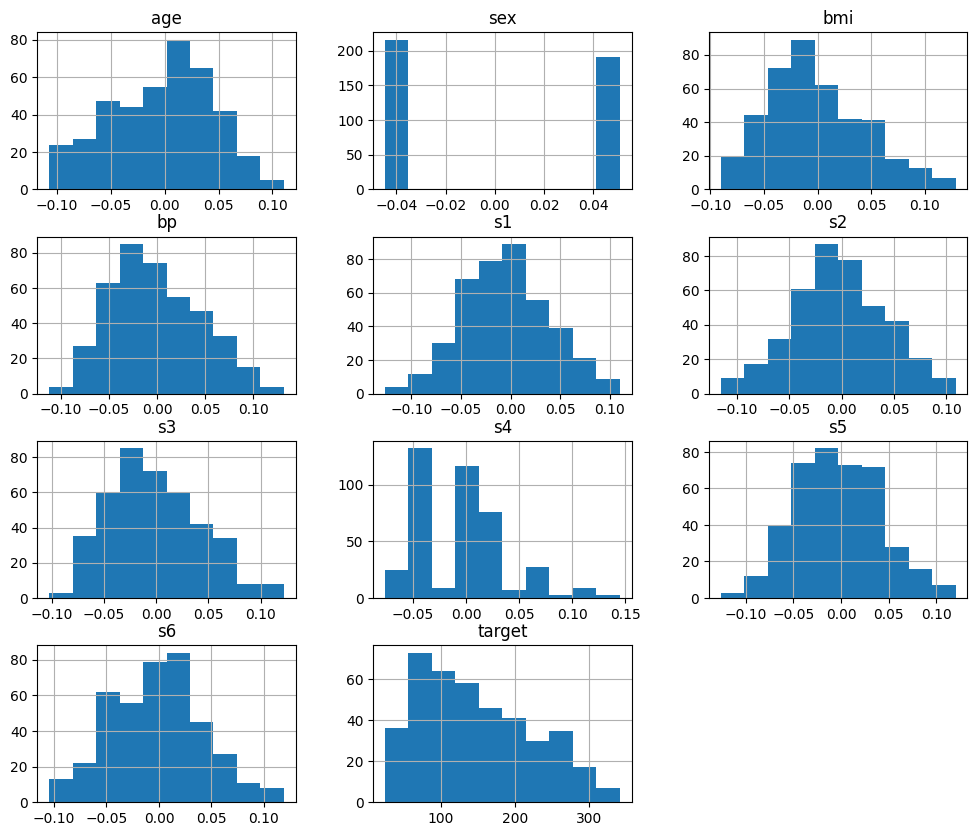

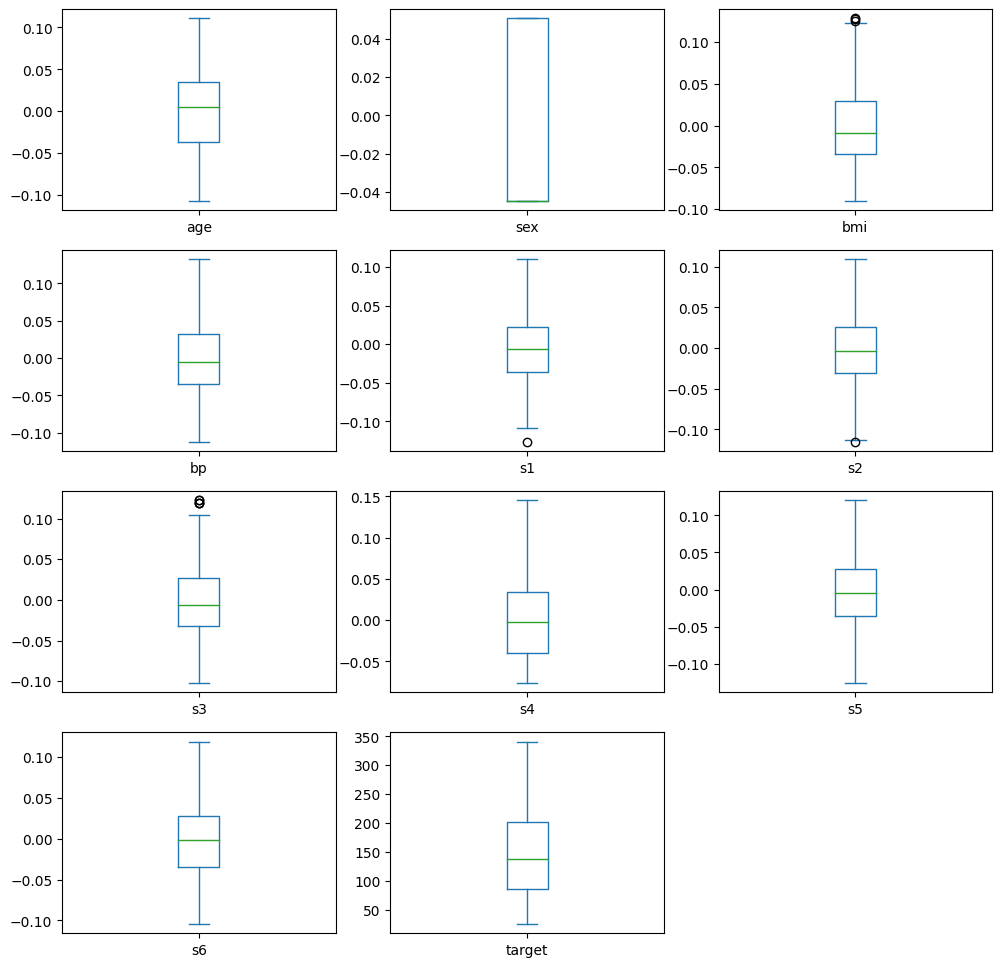

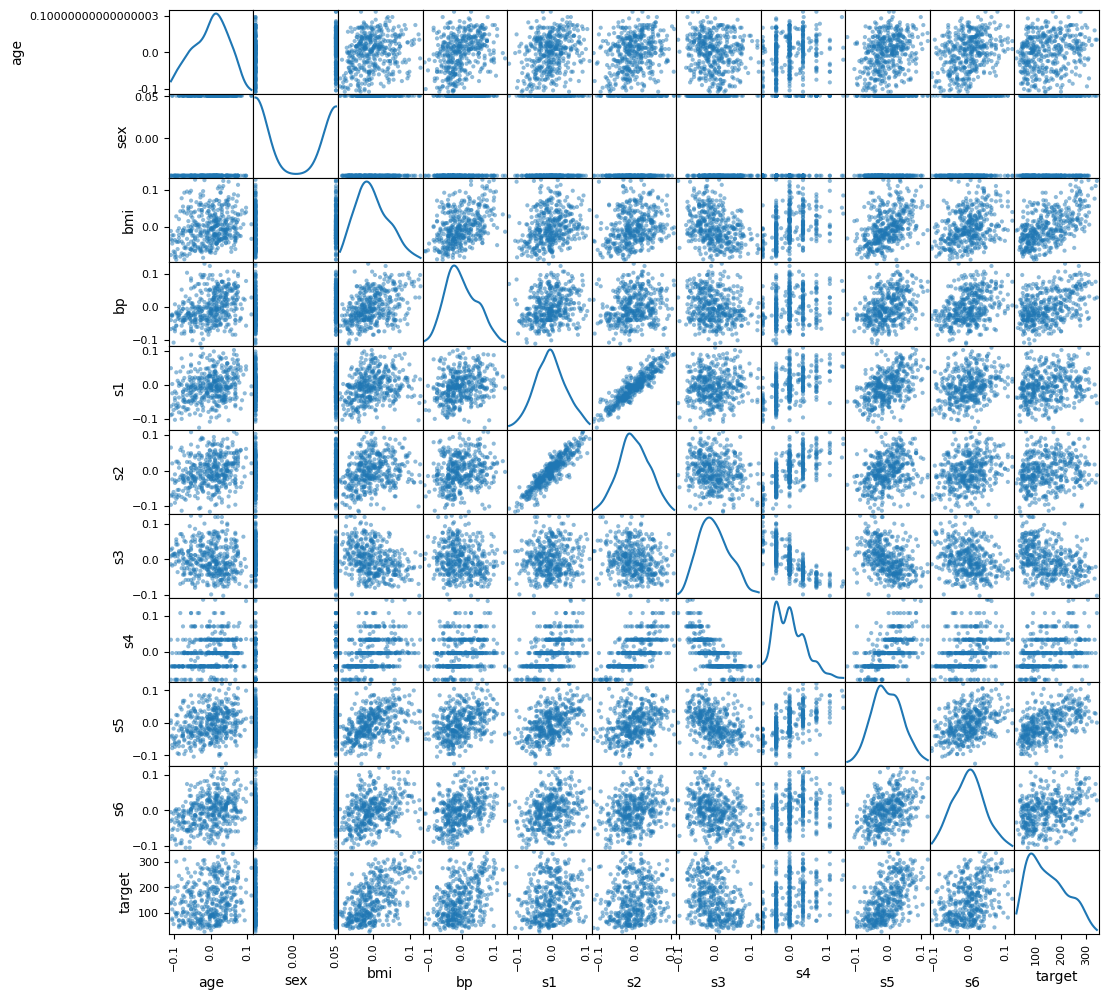

In [ ]:
#Гистограммы распределения для всех признаков
data_df.hist(figsize=(12, 10), bins=10)
plt.show()

#Box-and-Whisker диаграммы
data_df.plot(kind='box', subplots=True, layout=(4, 3), sharex=False, sharey=False, figsize=(12, 12))
plt.show()

#Диаграммы рассеяния для всех пар признаков
pd.plotting.scatter_matrix(data_df, alpha=0.5, figsize=(12, 12), diagonal='kde')
plt.show()


Выводы:

Характер распределений:
Большинство признаков имеют асимметричное распределение, например, 'age', 'sex', 'bmi', 's5', 's4'. Признак 'sex' является категориальным, поэтому для него некорректно использовать Box-and-Whisker диаграммы и гистограммы.

Некоторые признаки, такие как 'bp', 's1', 's2', 's3', 's5', 's6' имеют более близкое к нормальному распределение.

Наличие выбросов:
На диаграммах Box-and-Whisker видно, что некоторые признаки имеют выбросы, например: 'bmi', 's4', 's5'.


### 1.5 Корреляционный анализ данных


*Визуализировать диаграммы рассеяния и корреляционную матрицу признаков, сделать выводы*

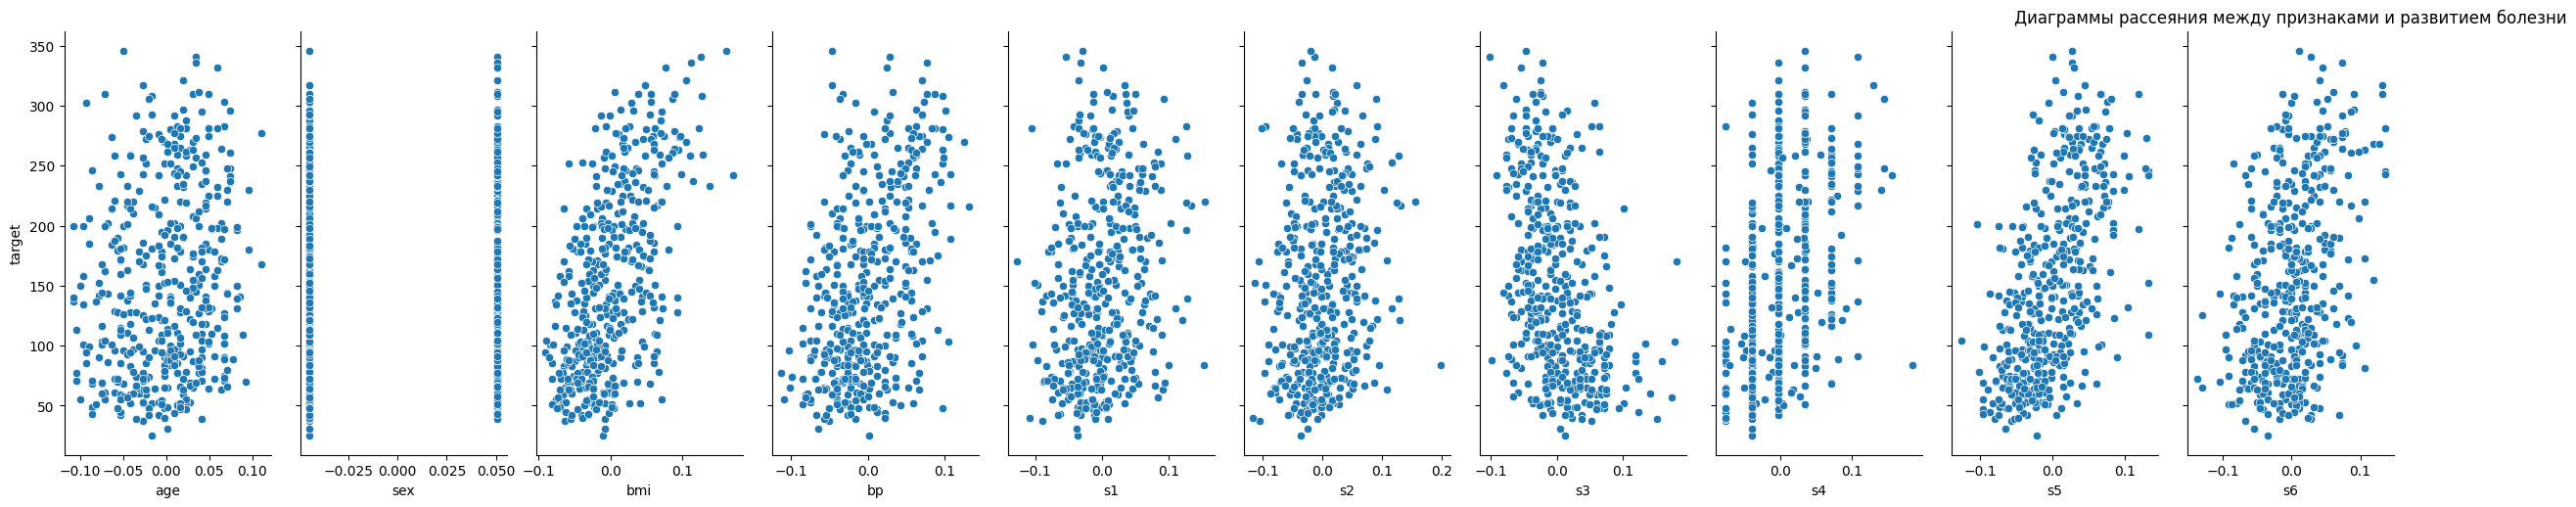

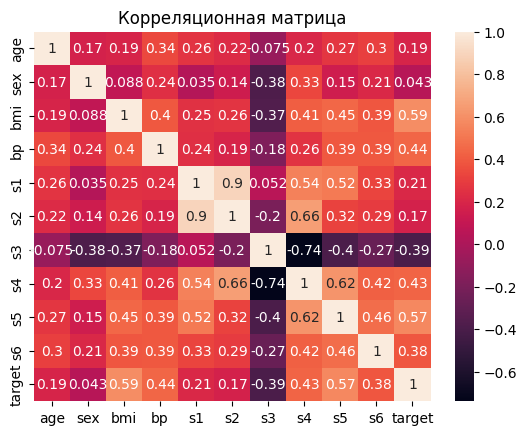

In [ ]:

sns.pairplot(data_df, x_vars=data.feature_names, y_vars='target', aspect=0.5, height = 5)
plt.title('Диаграммы рассеяния между признаками и развитием болезни')
plt.show()

corr_matrix = data_df.corr()
sns.heatmap(corr_matrix, annot=True)
plt.title('Корреляционная матрица')
plt.show()



Выводы:

  Диаграммы рассеяния:

  *   На диаграммах рессеяния зависимость прогрессирования болезни от некоторых признаков отдаленно напоминает линейную. Например: 'bmi', 'bp', 's5'
  *   От признака 'age' имеется слабовырожденная зависимость
  *   Взаимосвязь с признаком 's4' на диаграмме наблюдается сложная нелинейная зависимость
  *   Признаки 's1' и 's2' имеют вырожденную линейную зависимость

Корреляционная матрица:

  *   Наибольшая корреляция с 'target' наблюдается с признаками 'bmi', 'bp', 's5', 's4'
  *   Признаки 's1' и 's2' имеют сильную положительную корреляцию между србой и при этом слабовырожденую корреляцию с 'target', что может означать избыточность одного из этих двух признаков(либо обоих).
  *   Признаки 'age' и 'sex' имеют низкую корреляцию с 'target', что подтверждает их неоднозначную связь, наблюдаему. на диаграммах.

### 1.6 Выводы


*Сделать выводы по результатам предварительного визуального анализа исходных данных*

Выводы:

Характер распределений:
* Большинство признаков имеют асимметричное распределение, например, 'age', 'sex', 'bmi', 's5', 's4'.

* Некоторые признаки, такие как 'bp', 's1', 's2', 's3', 's5', 's6' имеют более близкое к нормальному распределение.

* Наличие выбросов: На диаграммах Box-and-Whisker видно, что некоторые признаки имеют выбросы, например: 'bmi', 's4', 's5'.

Диаграммы рассеяния:

* На диаграммах рессеяния зависимость прогрессирования болезни от некоторых признаков отдаленно напоминает линейную. Например: 'bmi', 'bp', 's5'
* От признака 'age' имеется слабовырожденная зависимость
* Взаимосвязь с признаком 's4' на диаграмме наблюдается сложная нелинейная зависимость

Корреляционная матрица:

* Наибольшая корреляция с 'target' наблюдается с признаками 'bmi', 'bp', 's5', 's4'
*   Признаки 's1' и 's2' имеют вырожденную линейную зависимость
* Признаки 's1' и 's2' имеют сильную положительную корреляцию между србой и при этом слабовырожденую корреляцию с 'target', что может означать избыточность одного из этих двух признаков(либо обоих).
* Признаки 'age' и 'sex' имеют низкую корреляцию с 'target', что подтверждает их неоднозначную связь, наблюдаему. на диаграммах.

---
# 2. Предобработка данных

### 2.1 Очистка данных


*а) Обнаружение и устранение дубликатов*\
*б) Обнаружение и устранение выбросов*\
*в) Устранение/восстановление пропущенных значений*

In [ ]:
#а)
data_df.drop_duplicates(inplace=True)
data_df

#б)Удаляем выбросы с помощью межквартильного диапазона, т.к. данные, в общем, не распределены нормально (Например: 'age', 'sex' и др.)
for column in data_df.columns:
    Q1 = data_df[column].quantile(0.25)
    Q3 = data_df[column].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    data_df = data_df[(data_df[column] >= lower_bound) & (data_df[column] <= upper_bound)]
#data_df

#в)
data_df.dropna(inplace=True)
data_df.isnull().sum()
data_df
#Пропущенных значений не было

,age,sex,bmi,bp,s1,s2,s3,s4,s5,s6,target
0,0.038076,0.050680,0.061696,0.021872,-0.044223,-0.034821,-0.043401,-0.002592,0.019907,-0.017646,151.0
1,-0.001882,-0.044642,-0.051474,-0.026328,-0.008449,-0.019163,0.074412,-0.039493,-0.068332,-0.092204,75.0
2,0.085299,0.050680,0.044451,-0.005670,-0.045599,-0.034194,-0.032356,-0.002592,0.002861,-0.025930,141.0
3,-0.089063,-0.044642,-0.011595,-0.036656,0.012191,0.024991,-0.036038,0.034309,0.022688,-0.009362,206.0
4,0.005383,-0.044642,-0.036385,0.021872,0.003935,0.015596,0.008142,-0.002592,-0.031988,-0.046641,135.0
...,...,...,...,...,...,...,...,...,...,...,...
436,-0.056370,-0.044642,-0.074108,-0.050427,-0.024960,-0.047034,0.092820,-0.076395,-0.061176,-0.046641,48.0
437,0.041708,0.050680,0.019662,0.059744,-0.005697,-0.002566,-0.028674,-0.002592,0.031193,0.007207,178.0
438,-0.005515,0.050680,-0.015906,-0.067642,0.049341,0.079165,-0.028674,0.034309,-0.018114,0.044485,104.0
439,0.041708,0.050680,-0.015906,0.017293,-0.037344,-0.013840,-0.024993,-0.011080,-0.046883,0.015491,132.0


### 2.2 Разбиение данных на обучающую и тестовую выборки


*Разбить данные на обучающую и тестовую выборки в отношении 70/30*

In [ ]:

X_train, X_test, y_train, y_test = train_test_split(
    data_df.drop('target', axis=1), data_df['target'], test_size=0.3)

print("Обучающая выборка (X_train):", X_train.shape)
print("Тестовая выборка (X_test):", X_test.shape)
print("Обучающая выборка (y_train):", y_train.shape)
print("Тестовая выборка (y_test):", y_test.shape)

Обучающая выборка (X_train): (284, 10)
Тестовая выборка (X_test): (123, 10)
Обучающая выборка (y_train): (284,)
Тестовая выборка (y_test): (123,)


### 2.3 Преобразование данных

* Описать используемые способы преобразования входных и выходных переменных, привести обоснования выбранных способов преобразования, применить преобразования к обучающей и тестовой выборкам*

TODO

In [ ]:

scaler = StandardScaler()
#X_train = scaler.fit_transform(X_train)
#X_test = scaler.fit_transform(X_test)


Данные изначально были преобразованны (см. п. 1.2). Эксперементальным путем было проверенно, что стандартизация данных так, чтобы они имели среднее значение 0 и стандартное отклонение 1,не дала положительный прирост r2 score.

---
# 3. Построение и исследование модели машинного обучения

### 3.1 Обучение модели


*Выбрать модель и алгоритм машинного обучения для решения поставленной задачи, привести обоснование выбора, обучить модель на обучающей выборке*

In [ ]:

model = LinearRegression()
model.fit(X_train, y_train)

LinearRegression()

### 3.2 Оценка качества модели


**Для задач регрессии:**
* *построить диаграммы рассеяния в пространстве «выход модели – желаемый выход» на данных обучающей и тестовой выборок*
* *построить линейные регрессии выхода модели на желаемый выход*
* *рассчитать коэффициенты детерминации линейных регрессионных моделей для обучающей и тестовой выборок*
* *построить гистограммы распределения ошибок модели.*

**Для задач классификации:**
* *построить матрицы ошибок (confusion matrix) классификатора и рассчитать показатели качества классификации (чувствительность, специфичность, точность, F-мера, каппа Коэна) на обучающей и тестовой выборках.*

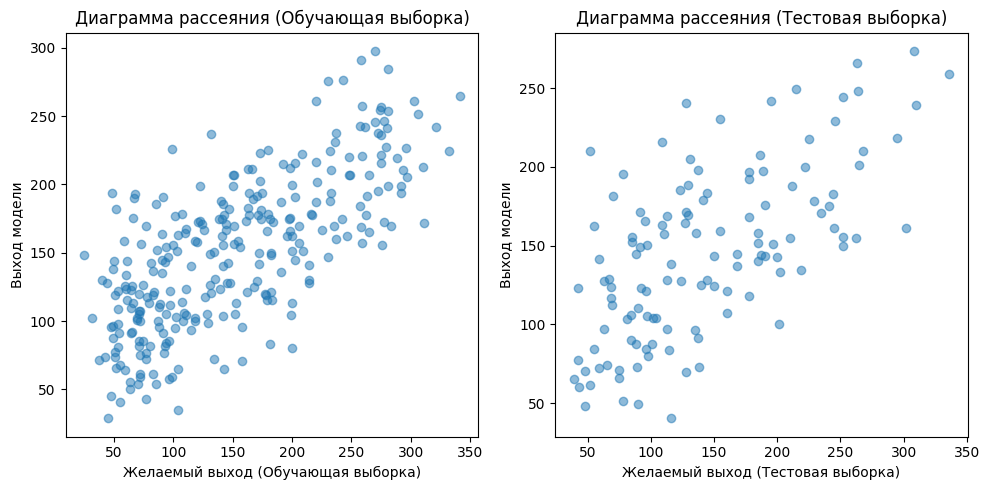

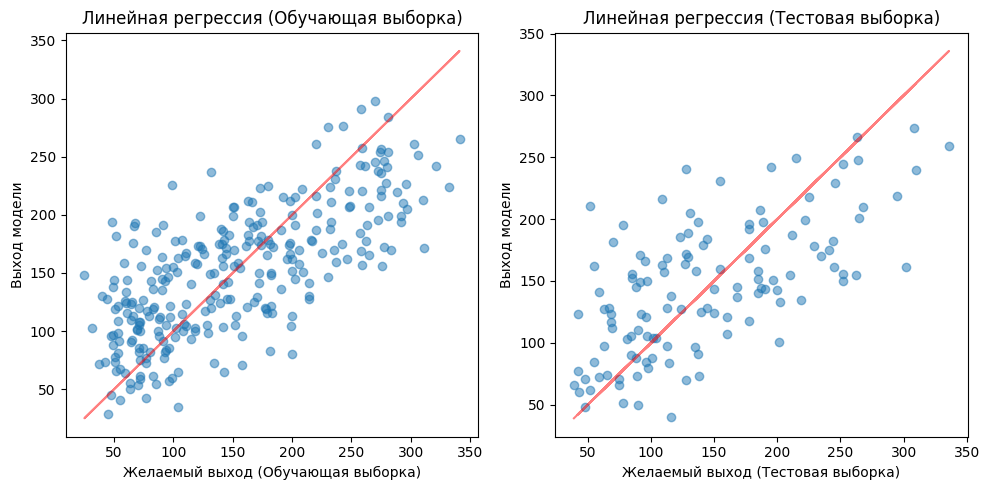

Коэффициент детерминации (Обучающая выборка): 0.5154861033531357
Коэффициент детерминации (Тестовая выборка): 0.4021873831871017
Среднеквадратичная ошибка (Обучающая выборка): 53.79416361176206
Среднеквадратичная ошибка (Тестовая выборка): 54.76296965812841


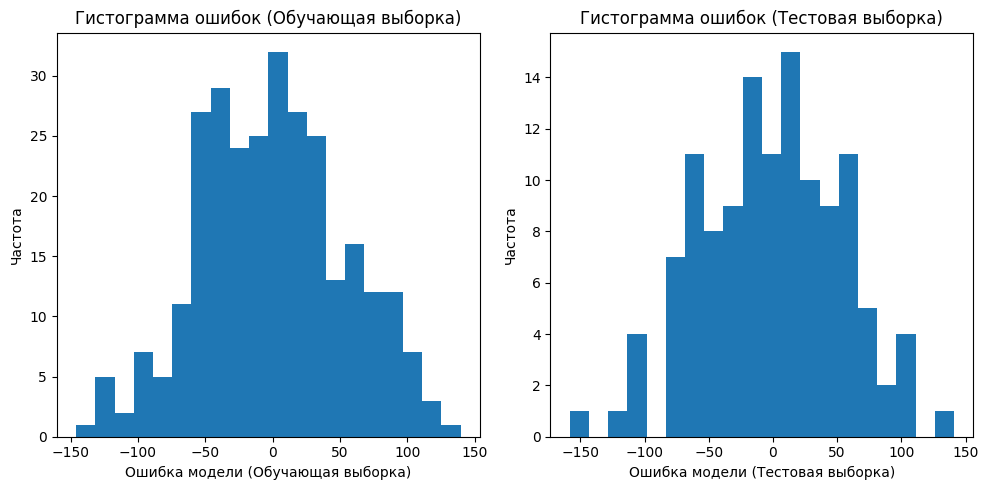

In [ ]:
y_pred_train = model.predict(X_train)
y_pred_test = model.predict(X_test)

def show_graphics(y_pred_train, y_pred_test):
  plt.figure(figsize=(10, 5))
  plt.subplot(1, 2, 1)
  plt.scatter(y_train, y_pred_train, alpha=0.5)
  plt.xlabel("Желаемый выход (Обучающая выборка)")
  plt.ylabel("Выход модели")
  plt.title("Диаграмма рассеяния (Обучающая выборка)")

  plt.subplot(1, 2, 2)
  plt.scatter(y_test, y_pred_test, alpha=0.5)
  plt.xlabel("Желаемый выход (Тестовая выборка)")
  plt.ylabel("Выход модели")
  plt.title("Диаграмма рассеяния (Тестовая выборка)")

  plt.tight_layout()
  plt.show()

  plt.figure(figsize=(10, 5))
  plt.subplot(1, 2, 1)
  plt.scatter(y_train, y_pred_train, alpha=0.5)
  plt.plot(y_train, y_train, color='red', alpha=0.5)
  plt.xlabel("Желаемый выход (Обучающая выборка)")
  plt.ylabel("Выход модели")
  plt.title("Линейная регрессия (Обучающая выборка)")

  plt.subplot(1, 2, 2)
  plt.scatter(y_test, y_pred_test, alpha=0.5)
  plt.plot(y_test, y_test, color='red', alpha=0.5)
  plt.xlabel("Желаемый выход (Тестовая выборка)")
  plt.ylabel("Выход модели")
  plt.title("Линейная регрессия (Тестовая выборка)")

  plt.tight_layout()
  plt.show()

  r2_train = r2_score(y_train, y_pred_train)
  r2_test = r2_score(y_test, y_pred_test)

  print("Коэффициент детерминации (Обучающая выборка):", r2_train)
  print("Коэффициент детерминации (Тестовая выборка):", r2_test)

  rmse_train = np.sqrt(mean_squared_error(y_train, y_pred_train))
  rmse_test = np.sqrt(mean_squared_error(y_test, y_pred_test))

  print("Среднеквадратичная ошибка (Обучающая выборка):", rmse_train)
  print("Среднеквадратичная ошибка (Тестовая выборка):", rmse_test)

  plt.figure(figsize=(10, 5))
  plt.subplot(1, 2, 1)
  plt.hist(y_train - y_pred_train, bins=20)
  plt.xlabel("Ошибка модели (Обучающая выборка)")
  plt.ylabel("Частота")
  plt.title("Гистограмма ошибок (Обучающая выборка)")

  plt.subplot(1, 2, 2)
  plt.hist(y_test - y_pred_test, bins=20)
  plt.xlabel("Ошибка модели (Тестовая выборка)")
  plt.ylabel("Частота")
  plt.title("Гистограмма ошибок (Тестовая выборка)")

  plt.tight_layout()
  plt.show()

show_graphics(y_pred_train, y_pred_test)

### 3.3 Исследование модели и алгоритма обучения


*Провести экспериментальные исследования модели, построить графики зависимости ошибки модели от ее архитектурных параметров и гиперпараметров алгоритма обучения, построить ROC-кривые, оценить степень важности признаков и пр.*

Узнаем на сколько точна будет kfold кросс валидация для линейной регрессии. Разбиваем на 3 фолда, чтобы отношение обучающих данных к тестовым было проимерно 70:30.

In [ ]:

model = LinearRegression()
r2_scores = cross_val_score(model, X_train, y_train, cv=3, scoring='r2')
rmse_scores = cross_val_score(model, X_train, y_train, cv=3, scoring='neg_root_mean_squared_error')
print("Коэффициент детерминации (Обучающая выборка):", np.mean(r2_scores))
print("Среднеквадратичная ошибка (Обучающая выборка):", -np.mean(rmse_scores))


Коэффициент детерминации (Обучающая выборка): 0.46235967951887647
Среднеквадратичная ошибка (Обучающая выборка): 56.5754105139688


При кросс валидации модель получается слабее, что скорее связанно с недостатком данных.

### 3.4 Улучшение решения

*Предложить возможное улучшение точности решения задачи (выбрать другой тип модели, алгоритм или критерий обучения, сформулировать рекомендации по возможным способам повышения точности модели), обучить модель и сравнить показатели точности с рассчитанными в п.3.2*

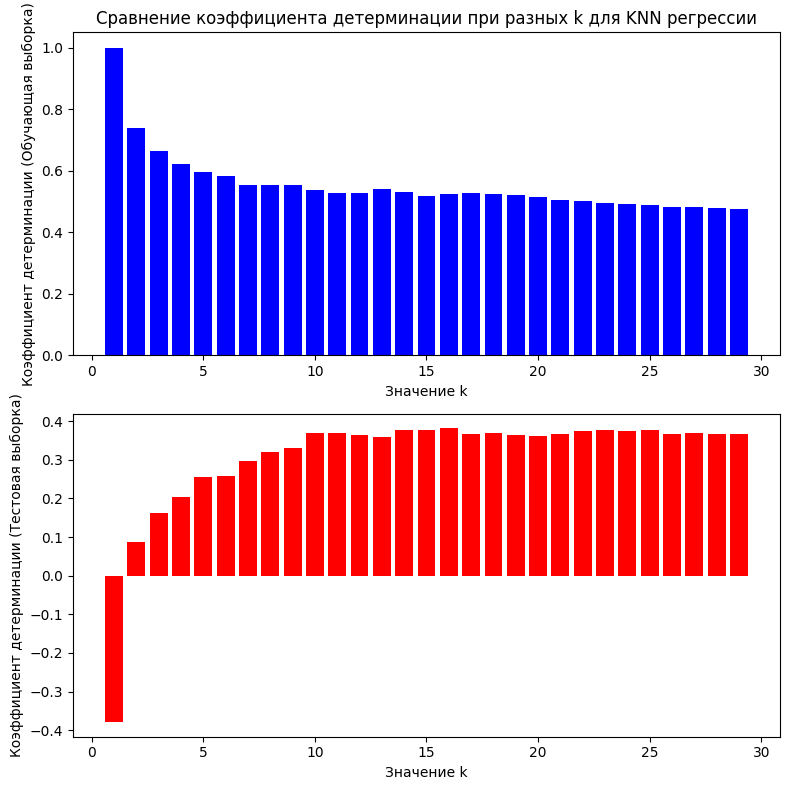

In [ ]:

k = range(1,30)
r2_train = []
r2_test = []

for i in k:
  model = KNeighborsRegressor(n_neighbors=i)

  model.fit(X_train, y_train)

  y_pred_train = model.predict(X_train)
  y_pred_test = model.predict(X_test)
  r2_train.append(r2_score(y_train, y_pred_train))
  r2_test.append(r2_score(y_test, y_pred_test))

plt.figure(figsize=(8,8))
plt.subplot(2, 1, 1)
plt.title('Сравнение коэффициента детерминации при разных k для KNN регрессии')
plt.bar(k, r2_train, color='blue')
plt.xlabel('Значение k')
plt.ylabel('Коэффициент детерминации (Обучающая выборка)')

plt.subplot(2, 1, 2)
plt.bar(k, r2_test, color='red')
plt.xlabel('Значение k')
plt.ylabel('Коэффициент детерминации (Тестовая выборка)')

plt.tight_layout()
plt.show()


По графикам, видно, что наболее сбаллансированы коэффициенты детерминации на обучающей и тестовой выборках, при k = ?. Значение может меняться при каждом отдельном запуске, надо каждый раз смотреть графики.

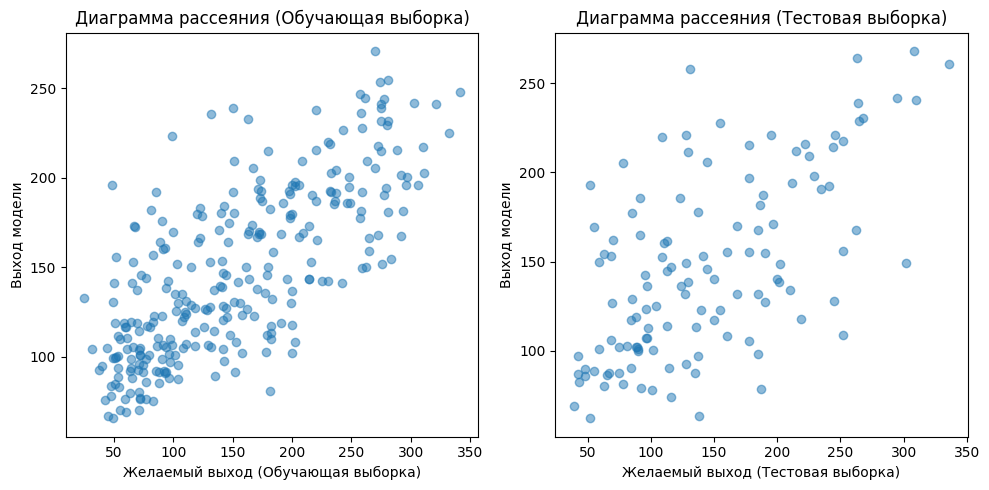

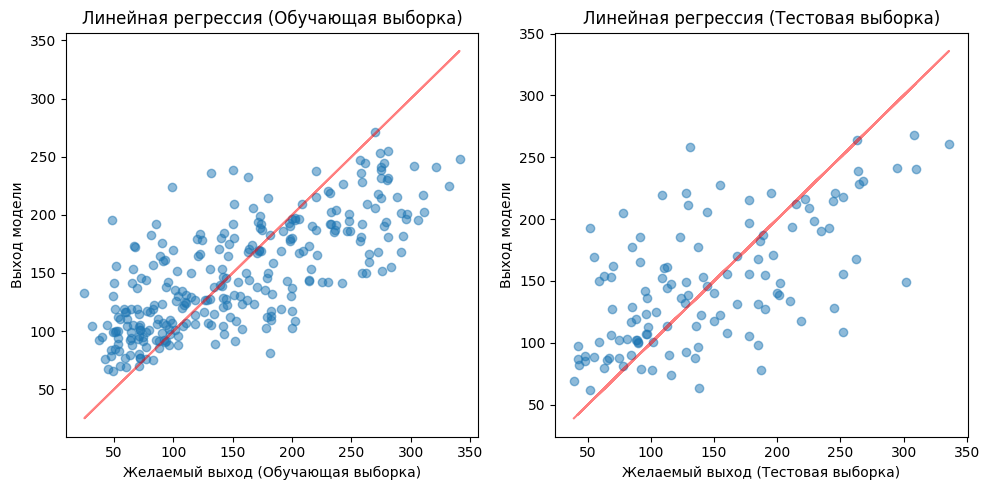

Коэффициент детерминации (Обучающая выборка): 0.5286129987252572
Коэффициент детерминации (Тестовая выборка): 0.36858840847825136
Среднеквадратичная ошибка (Обучающая выборка): 53.06043936698711
Среднеквадратичная ошибка (Тестовая выборка): 56.280860348352554


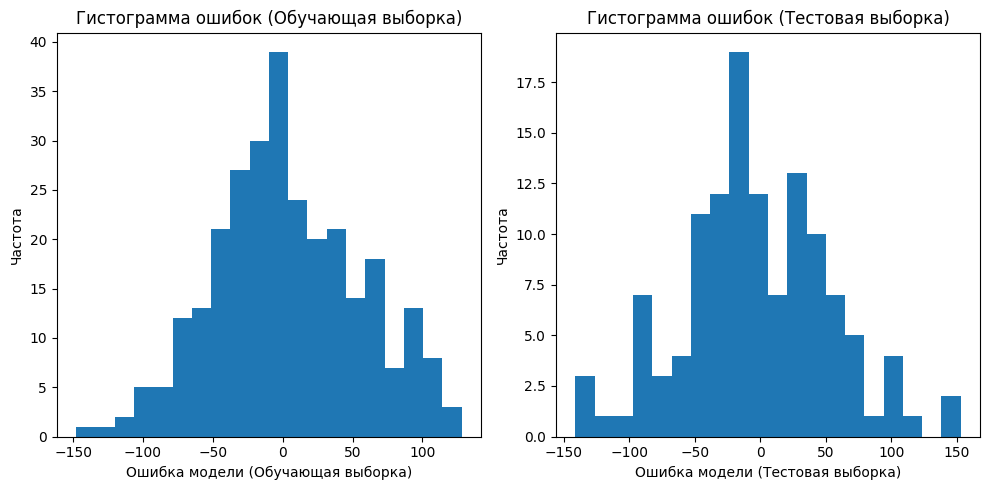

In [ ]:
model = KNeighborsRegressor(n_neighbors=11)

model.fit(X_train, y_train)

y_pred_train = model.predict(X_train)
y_pred_test = model.predict(X_test)

show_graphics(y_pred_train, y_pred_test)

KNN регрессия дала прирост в метрике R2 score на тестовой выборке, но при этом потерю качества на обучающей выборке. Среднеквадратическая ошибка не изменилась.
Теперь удалим слабо коррелирующие с 'target' признаки из датасета.

In [ ]:
X_train.drop(['age', 's2', 's4'], axis=1, inplace=True)
X_test.drop(['age', 's2', 's4'], axis=1, inplace=True)

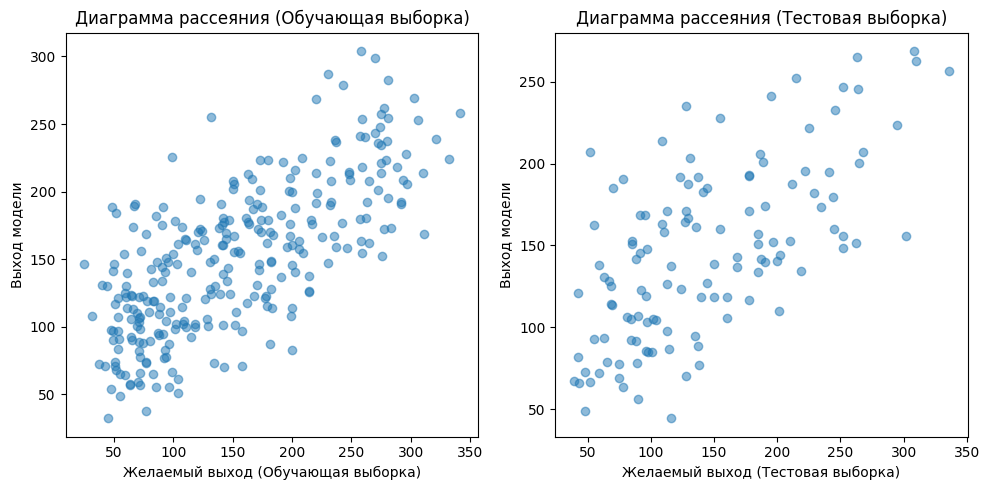

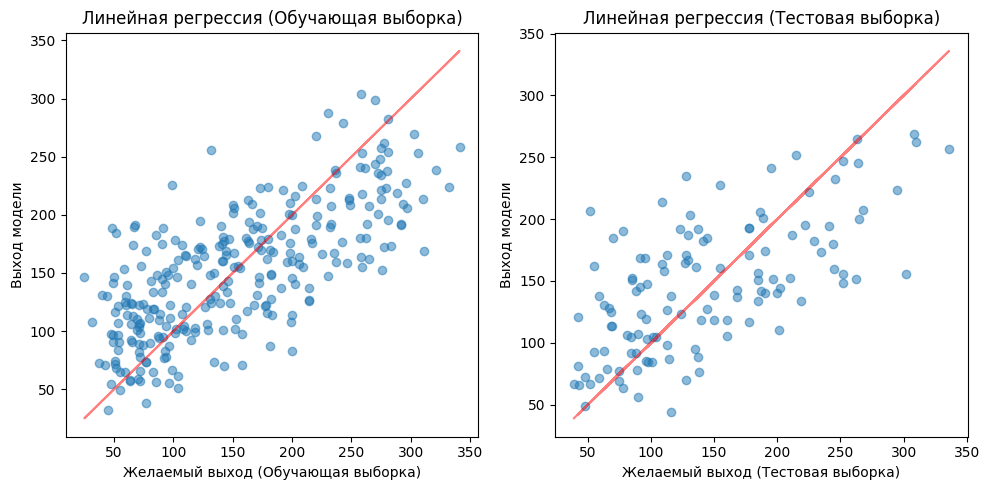

Коэффициент детерминации (Обучающая выборка): 0.5127168588412861
Коэффициент детерминации (Тестовая выборка): 0.41545312999652717
Среднеквадратичная ошибка (Обучающая выборка): 53.94767514233947
Среднеквадратичная ошибка (Тестовая выборка): 54.15195275787431


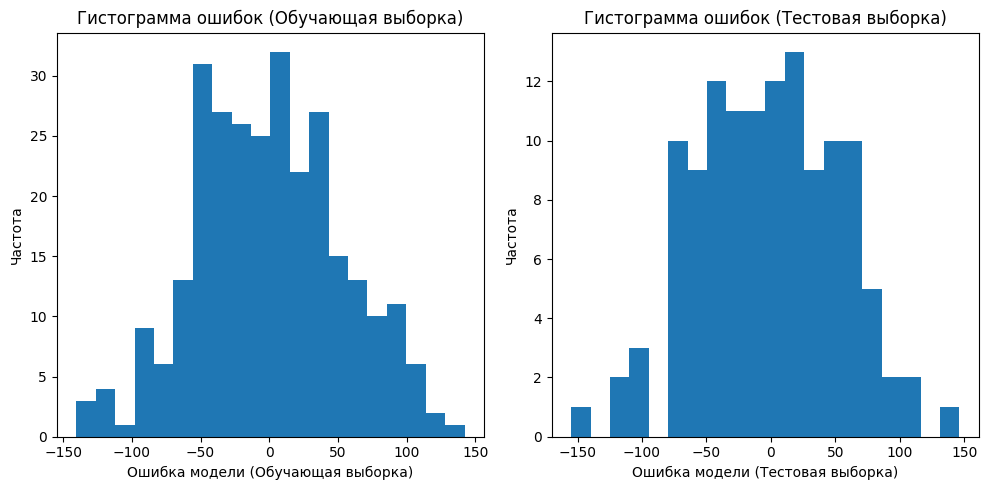

In [ ]:
model = LinearRegression()
model.fit(X_train, y_train)

y_pred_train = model.predict(X_train)
y_pred_test = model.predict(X_test)

show_graphics(y_pred_train, y_pred_test)

Эксперементальным путем, принимая во внимание таблицу корреляции были удалены признаки, которые слабо коррелировали с 'target'.
Удаление признаков скозалось положительно на точности модели на тестовой выыборке.

### 3.5 Выводы


*Сделать выводы по результатам проведенных исследований*

В ходе проведенного исследования, были построенны графики распределений, гистограммы и диаграммы Box-and-Whisker данных, а также посчитаны их характеристики и корреляция. Были найдены недостатки и особенности в данном датасате и предложены способы разрешения некоторых из них.

Далее данные были очищены от выбросов и пустых значений, обработаны и разбиты на обучающую и тестовую выборки.

В следующем этапе был выбран алгоритм машинного обучения для решения поставленной задачи - линейная регрессия. Модель была обучена и были построенны построить диаграммы рассеяния, линейные регрессии и гистограммы распределения ошибок модели. На их основе была произведена отценка модели, в ходе которой выявлены недостатки в модели, в данных и в алгоритме обучения.

Далее проводились исследовательские эксперементы со стандартизацией данных, кросс валлидацией, использованием другой модели(Регрессии 'ка' ближайших соседей), с удалением избыточных параметров. В ходе работы получены выводы про то, как все вышеперечисленные подходы вылияют на точность и качество решения хадачи регрессии.

В результате, изначальная линейная регрессия с удаленными избыточными парраметрами оказалась с наибольшим коэффициентом детерминации и с наименьшой среднеквадратичной ошибкой. Но очевидно, что сушествуют алгоритмы машинного обучения, подходы к обработке данных, которые справятся лучше с этой задачей. И прочие инструменты машинного обучения.